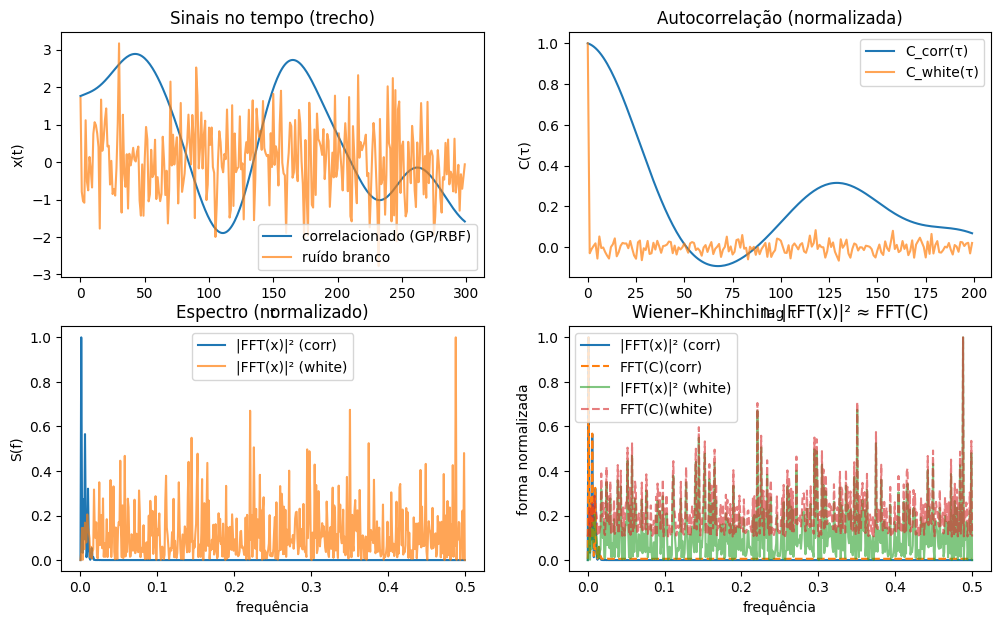

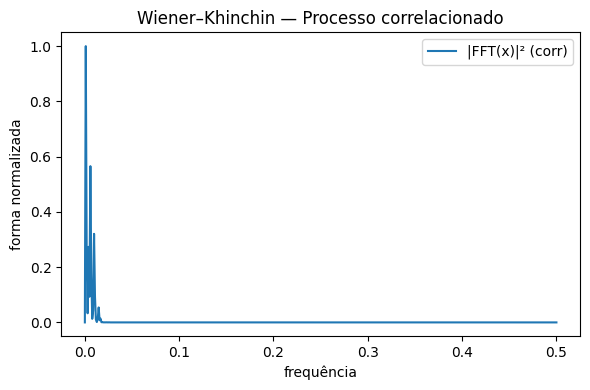

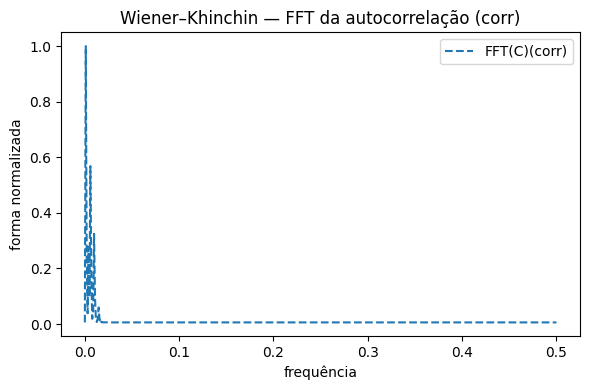

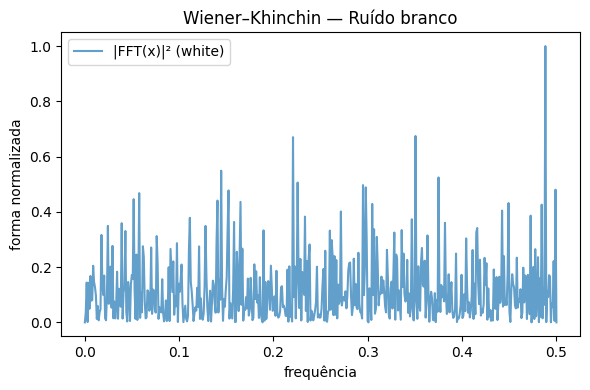

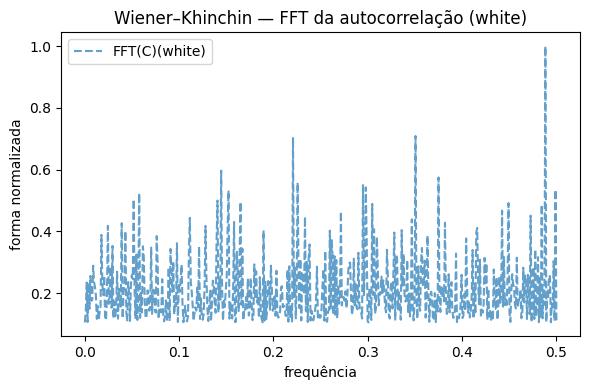

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ------------------------------------------------------------
# 1) Toy model: processo Gaussiano estacionário (RBF kernel)
#    x ~ N(0, K), onde K_ij = exp(-(t_i - t_j)^2 / (2ℓ^2))
# ------------------------------------------------------------
def rbf_kernel(t, ell=10.0, sigma=1.0):
    dt = t[:, None] - t[None, :]
    return (sigma**2) * np.exp(-(dt**2) / (2 * ell**2))

def sample_gp(t, ell=10.0, sigma=1.0, jitter=1e-10):
    K = rbf_kernel(t, ell=ell, sigma=sigma) + jitter*np.eye(len(t))
    L = np.linalg.cholesky(K)
    z = np.random.randn(len(t))
    return L @ z  # amostra correlacionada

# grade "temporal"
N = 1024
t = np.arange(N)

# sinal correlacionado (suave) e ruído branco
x_corr = sample_gp(t, ell=25.0, sigma=1.0)
x_white = np.random.randn(N)

# ------------------------------------------------------------
# 2) Autocorrelação amostral (via correlação + normalização)
#    para processo estacionário, C(τ) depende só do lag
# ------------------------------------------------------------
def autocorr(x):
    x = x - np.mean(x)
    c = np.correlate(x, x, mode="full")
    c = c[c.size // 2:]                  # lags >= 0
    c = c / c[0]                         # normaliza: C(0)=1
    return c

C_corr = autocorr(x_corr)
C_white = autocorr(x_white)

# ------------------------------------------------------------
# 3) Espectro via FFT
#    Wiener-Khinchin: FFT(autocorr) ~ |FFT(x)|^2 (até constante)
# ------------------------------------------------------------
def power_spectrum(x):
    x = x - np.mean(x)
    X = np.fft.rfft(x)
    S = (np.abs(X)**2) / len(x)          # periodograma simples
    return S

S_corr = power_spectrum(x_corr)
S_white = power_spectrum(x_white)

# espectro "predito" a partir da autocorrelação (W-K)
# (usamos FFT real da autocorr; para comparação, normalizamos)
S_from_C_corr = np.fft.rfft(C_corr)
S_from_C_white = np.fft.rfft(C_white)

S_from_C_corr = np.real(S_from_C_corr)
S_from_C_white = np.real(S_from_C_white)

# normaliza para comparar forma (não amplitude)
S_from_C_corr /= S_from_C_corr.max()
S_from_C_white /= S_from_C_white.max()

S_corr_norm = S_corr / S_corr.max()
S_white_norm = S_white / S_white.max()

# ------------------------------------------------------------
# 4) Plots
# ------------------------------------------------------------
fig, ax = plt.subplots(2, 2, figsize=(12, 7))

# sinais
ax[0,0].plot(t[:300], x_corr[:300], label="correlacionado (GP/RBF)")
ax[0,0].plot(t[:300], x_white[:300], label="ruído branco", alpha=0.7)
ax[0,0].set_title("Sinais no tempo (trecho)")
ax[0,0].legend()
ax[0,0].set_xlabel("t")
ax[0,0].set_ylabel("x(t)")

# autocorrelação
lags = np.arange(200)
ax[0,1].plot(lags, C_corr[:200], label="C_corr(τ)")
ax[0,1].plot(lags, C_white[:200], label="C_white(τ)", alpha=0.7)
ax[0,1].set_title("Autocorrelação (normalizada)")
ax[0,1].legend()
ax[0,1].set_xlabel("lag τ")
ax[0,1].set_ylabel("C(τ)")

# espectro
freq = np.fft.rfftfreq(N, d=1.0)
ax[1,0].plot(freq, S_corr_norm, label="|FFT(x)|² (corr)")
ax[1,0].plot(freq, S_white_norm, label="|FFT(x)|² (white)", alpha=0.7)
ax[1,0].set_title("Espectro (normalizado)")
ax[1,0].legend()
ax[1,0].set_xlabel("frequência")
ax[1,0].set_ylabel("S(f)")

# checagem Wiener–Khinchin (forma)
ax[1,1].plot(freq, S_corr_norm, label="|FFT(x)|² (corr)")
ax[1,1].plot(freq, S_from_C_corr, "--", label="FFT(C)(corr)")
ax[1,1].plot(freq, S_white_norm, label="|FFT(x)|² (white)", alpha=0.6)
ax[1,1].plot(freq, S_from_C_white, "--", label="FFT(C)(white)", alpha=0.6)
ax[1,1].set_title("Wiener–Khinchin: |FFT(x)|² ≈ FFT(C)")
ax[1,1].legend()
ax[1,1].set_xlabel("frequência")
ax[1,1].set_ylabel("forma normalizada")


# ------------------------------------------------------------
# 4b) Wiener–Khinchin em gráficos separados
# ------------------------------------------------------------

# 1) Processo correlacionado: |FFT(x)|^2
plt.figure(figsize=(6, 4))
plt.plot(freq, S_corr_norm, label="|FFT(x)|² (corr)")
plt.title("Wiener–Khinchin — Processo correlacionado")
plt.xlabel("frequência")
plt.ylabel("forma normalizada")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Processo correlacionado: FFT(C)
plt.figure(figsize=(6, 4))
plt.plot(freq, S_from_C_corr, "--", label="FFT(C)(corr)")
plt.title("Wiener–Khinchin — FFT da autocorrelação (corr)")
plt.xlabel("frequência")
plt.ylabel("forma normalizada")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Ruído branco: |FFT(x)|^2
plt.figure(figsize=(6, 4))
plt.plot(freq, S_white_norm, label="|FFT(x)|² (white)", alpha=0.7)
plt.title("Wiener–Khinchin — Ruído branco")
plt.xlabel("frequência")
plt.ylabel("forma normalizada")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Ruído branco: FFT(C)
plt.figure(figsize=(6, 4))
plt.plot(freq, S_from_C_white, "--", label="FFT(C)(white)", alpha=0.7)
plt.title("Wiener–Khinchin — FFT da autocorrelação (white)")
plt.xlabel("frequência")
plt.ylabel("forma normalizada")
plt.legend()
plt.tight_layout()
plt.show()

